In [1]:
# @title 1) Student Info & Config
STUDENT_NAME = "Воропаев Фёдор Игоревич"  # @param {type:"string"}
GROUP = "11-301"         # @param {type:"string"}
ASSIGMENT = "HW4_METRICS_THRESHOLD"
SEED = 42
START_DATE = "2026-03-23"
DUE_DATE = "2026-04-07"


# HW4 — Метрики и пороги (threshold tuning)

**Тема:** Accuracy vs Precision/Recall/F1, confusion matrix, PR-AUC, ROC-AUC, подбор threshold под стоимость ошибок.

Вы сделаете мини-пайплайн оценки бинарного классификатора:
- посчитаете confusion matrix и основные метрики
- сравните **accuracy** и **F1** при дисбалансе классов
- построите **threshold sweep** и выберете рабочую точку (operating point)
- выберете порог по **матрице стоимости ошибок**
- посчитаете **PR-AUC** и **ROC-AUC**

**Правила**
- Не редактируйте ячейки тестов и подсчёта баллов.
- Перед сдачей: `Runtime → Restart and run all`.
- Итог: `TOTAL POINTS / 100` + финальный JSON в последней ячейке.


In [5]:
import random
from datetime import datetime, timezone
from typing import Dict, Tuple, List, Any

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix as sk_confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

plt.rcParams["figure.dpi"] = 140

# ---------------- Reproducibility ----------------
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)

seed_everything(SEED)

# ---------------- Dates for penalty logic (used by last cell) ----------------
def _parse_date(s: str):
    try:
        return datetime.strptime(s, "%Y-%m-%d").replace(tzinfo=timezone.utc)
    except Exception:
        return None

def _sec(td) -> float:
    return float(td.total_seconds())

start_dt = _parse_date(START_DATE)
due_dt = _parse_date(DUE_DATE)
submission_dt = datetime.now(timezone.utc)

# ---------------- Scoring ----------------
SCORES: Dict[str, float] = {}

def _set_score(task: str, pts: float):
    SCORES[task] = float(pts)

def _total_score() -> float:
    return float(sum(SCORES.values()))

def _print_scores():
    print("Scores:")
    for k in sorted(SCORES.keys()):
        print(f"  {k}: {SCORES[k]:.1f}")
    print("TOTAL:", _total_score())

def _assert(cond: bool, msg: str):
    if not cond:
        raise AssertionError(msg)


## Данные (synthetic)

Мы используем синтетические данные, чтобы не скачивать датасеты и иметь контролируемые условия.

Есть 2 набора:
- **dev**: для выбора threshold
- **test**: для финальной проверки (порог по test не подбираем)

Термины:
- `y_true` — истинная метка (0/1)
- `y_score` — score модели (0..1), чем выше, тем “позитивнее”
- `threshold` — порог: если `y_score >= threshold`, то предсказываем 1


dev positives: 121 / 4000
test positives: 115 / 4000


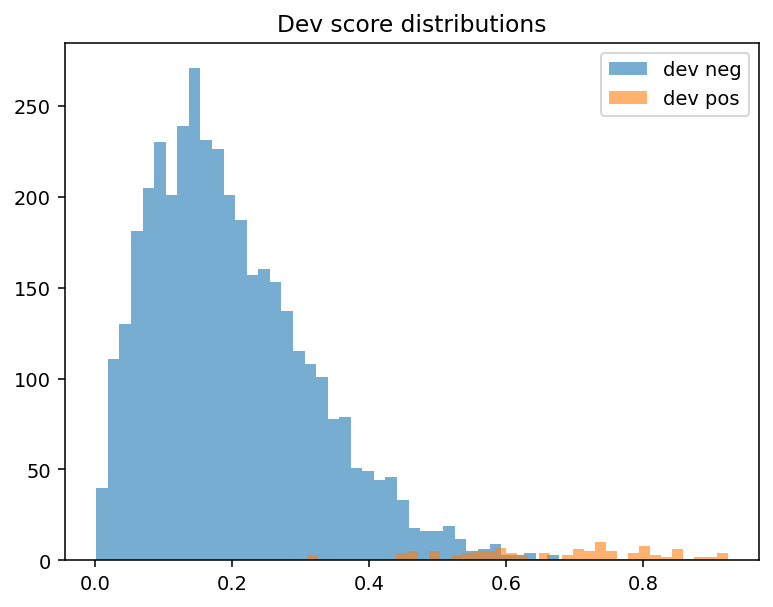

In [6]:
def make_scores(n: int, prevalence: float, shift: float, seed: int) -> Tuple[np.ndarray, np.ndarray]:
    """Return (y_true, y_score). y_score in [0,1]."""
    rng = np.random.RandomState(seed)
    y_true = (rng.rand(n) < prevalence).astype(int)

    # Negatives: mostly low scores
    neg = rng.beta(a=2.0, b=8.0, size=n)

    # Positives: shifted higher
    pos = rng.beta(a=6.0, b=3.0, size=n)

    scores = np.where(y_true == 1, pos, neg)

    # Domain shift (simulate change in conditions)
    scores = np.clip(scores + shift * rng.normal(0, 0.08, size=n), 0, 1)
    return y_true, scores

DEV_N = 4000
TEST_N = 4000
PREVALENCE = 0.03  # 3% positives (rare events)

y_dev, s_dev = make_scores(DEV_N, PREVALENCE, shift=0.0, seed=SEED)
y_test, s_test = make_scores(TEST_N, PREVALENCE, shift=0.15, seed=SEED + 7)

print("dev positives:", int(y_dev.sum()), "/", len(y_dev))
print("test positives:", int(y_test.sum()), "/", len(y_test))

plt.hist(s_dev[y_dev==0], bins=40, alpha=0.6, label="dev neg")
plt.hist(s_dev[y_dev==1], bins=40, alpha=0.6, label="dev pos")
plt.title("Dev score distributions")
plt.legend()
plt.show()


## Задания и баллы (100)

- **Task 1 (15 pts)** — confusion matrix вручную (`my_confusion_matrix`)
- **Task 2 (15 pts)** — метрики: accuracy, precision, recall, F1 (`my_metrics`)
- **Task 3 (10 pts)** — предсказание по порогу (`predict_by_threshold`)
- **Task 4 (20 pts)** — threshold sweep и выбор operating point по ограничению (`choose_threshold_by_constraint`)
- **Task 5 (20 pts)** — PR-AUC и ROC-AUC + кривые (`compute_auc_and_curves`)
- **Task 6 (20 pts)** — выбор threshold по матрице стоимости ошибок (`choose_threshold_by_cost`)


## Task 1 (15 pts) — Confusion matrix

Confusion matrix для бинарной классификации — это 4 числа:
- **TP**: предсказали 1 и истинно 1
- **FP**: предсказали 1, а истинно 0 (ложная тревога)
- **FN**: предсказали 0, а истинно 1 (пропуск)
- **TN**: предсказали 0 и истинно 0

Реализуйте `my_confusion_matrix(y_true, y_pred)` и верните `(tp, fp, fn, tn)`.


In [ ]:
# TODO: implement
def my_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[int, int, int, int]:
    """Return (tp, fp, fn, tn) for binary labels 0/1."""
    # YOUR CODE HERE
    raise NotImplementedError()


In [ ]:
# Tests for Task 1
try:
    rng = np.random.RandomState(123)
    yt = rng.randint(0, 2, size=200)
    yp = rng.randint(0, 2, size=200)
    tp, fp, fn, tn = my_confusion_matrix(yt, yp)
    cm = sk_confusion_matrix(yt, yp, labels=[0,1])  # [[tn, fp],[fn,tp]]
    _assert((tn, fp, fn, tp) == (int(cm[0,0]), int(cm[0,1]), int(cm[1,0]), int(cm[1,1])),
            "Confusion matrix values mismatch with sklearn")
    _set_score("task1", 15)
    print("✅ Task 1 passed")
except Exception as e:
    print("❌ Task 1 failed:", e)
    _set_score("task1", 0)


## Task 2 (15 pts) — Accuracy / Precision / Recall / F1

Определения:
- **Accuracy**: доля правильных ответов среди всех.
- **Precision**: среди предсказанных “1” сколько истинных “1”.
- **Recall**: среди истинных “1” сколько нашли.
- **F1**: гармоническое среднее precision и recall.

Реализуйте `my_metrics(y_true, y_pred)` и верните:
`{"accuracy": ..., "precision": ..., "recall": ..., "f1": ...}`


In [ ]:
# TODO: implement
def my_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    # YOUR CODE HERE
    raise NotImplementedError()


In [ ]:
# Tests for Task 2
try:
    rng = np.random.RandomState(7)
    yt = rng.randint(0, 2, size=500)
    yp = rng.randint(0, 2, size=500)
    m = my_metrics(yt, yp)
    for k in ["accuracy","precision","recall","f1"]:
        _assert(k in m, f"Missing key: {k}")
        _assert(isinstance(m[k], (int,float,np.floating)), f"Metric {k} must be numeric")
    _assert(abs(m["accuracy"] - accuracy_score(yt, yp)) < 1e-9, "Accuracy mismatch")
    _assert(abs(m["precision"] - precision_score(yt, yp, zero_division=0)) < 1e-9, "Precision mismatch")
    _assert(abs(m["recall"] - recall_score(yt, yp, zero_division=0)) < 1e-9, "Recall mismatch")
    _assert(abs(m["f1"] - f1_score(yt, yp, zero_division=0)) < 1e-9, "F1 mismatch")
    _set_score("task2", 15)
    print("✅ Task 2 passed")
except Exception as e:
    print("❌ Task 2 failed:", e)
    _set_score("task2", 0)


## Task 3 (10 pts) — Предсказание по порогу

Threshold превращает score в класс:
- если `score >= threshold` → 1
- иначе → 0

Реализуйте `predict_by_threshold(y_score, threshold)`.


In [ ]:
# TODO: implement
def predict_by_threshold(y_score: np.ndarray, threshold: float) -> np.ndarray:
    # YOUR CODE HERE
    raise NotImplementedError()


In [ ]:
# Tests for Task 3
try:
    s = np.array([0.0, 0.2, 0.5, 0.50001, 0.9])
    yp = predict_by_threshold(s, 0.5)
    _assert(yp.dtype.kind in ("i","u","b"), "y_pred must be integer/bool array")
    _assert(yp.tolist() == [0,0,1,1,1], "Rule must be: score >= threshold => 1")
    _set_score("task3", 10)
    print("✅ Task 3 passed")
except Exception as e:
    print("❌ Task 3 failed:", e)
    _set_score("task3", 0)


## Task 4 (20 pts) — Threshold sweep и operating point по ограничению

Выбираем порог на dev так:
- Требуем **Recall >= target_recall**
- Среди порогов, которые проходят ограничение, выбираем тот, где **Precision максимален**
- Если ни один порог не проходит — возвращаем `None`

Реализуйте `choose_threshold_by_constraint(y_true, y_score, target_recall)`.


In [ ]:
# TODO: implement
def choose_threshold_by_constraint(y_true: np.ndarray, y_score: np.ndarray, target_recall: float) -> float:
    """Return threshold that achieves recall>=target_recall and maximizes precision on dev."""
    # YOUR CODE HERE
    raise NotImplementedError()


In [ ]:
# Tests for Task 4
try:
    thr = choose_threshold_by_constraint(y_dev, s_dev, target_recall=0.85)
    _assert(thr is not None, "Expected a valid threshold for target_recall=0.85 on dev")
    yp = predict_by_threshold(s_dev, thr)
    m = my_metrics(y_dev, yp)
    _assert(m["recall"] >= 0.85 - 1e-9, "Chosen threshold must satisfy recall constraint on dev")

    thresholds = np.unique(np.round(s_dev, 4))
    best_p = -1
    for t in thresholds:
        ypi = predict_by_threshold(s_dev, float(t))
        mi = my_metrics(y_dev, ypi)
        if mi["recall"] >= 0.85 - 1e-9:
            best_p = max(best_p, mi["precision"])
    _assert(m["precision"] >= best_p - 1e-3, "Threshold does not maximize precision among feasible thresholds (tolerance 1e-3)")
    _set_score("task4", 20)
    print("✅ Task 4 passed")
except Exception as e:
    print("❌ Task 4 failed:", e)
    _set_score("task4", 0)


## Task 5 (20 pts) — PR-AUC и ROC-AUC + кривые

Определения:
- **ROC-AUC**: площадь под ROC-кривой (TPR vs FPR).
- **PR-AUC**: площадь под PR-кривой (Precision vs Recall), обычно честнее при редком позитиве.

Реализуйте `compute_auc_and_curves(y_true, y_score)` и верните:
- `roc_auc`
- `pr_auc`
- `roc_curve`: (fpr, tpr, thresholds)
- `pr_curve`: (precision, recall, thresholds)

После реализации постройте ROC и PR графики.


In [ ]:
# TODO: implement
def compute_auc_and_curves(y_true: np.ndarray, y_score: np.ndarray) -> Dict[str, Any]:
    # YOUR CODE HERE
    raise NotImplementedError()

# Optional plotting area (after implementation)


In [ ]:
# Tests for Task 5
try:
    res = compute_auc_and_curves(y_dev, s_dev)
    for k in ["roc_auc","pr_auc","roc_curve","pr_curve"]:
        _assert(k in res, f"Missing key: {k}")
    _assert(0.0 <= float(res["roc_auc"]) <= 1.0, "roc_auc must be in [0,1]")
    _assert(0.0 <= float(res["pr_auc"]) <= 1.0, "pr_auc must be in [0,1]")
    _assert(abs(float(res["roc_auc"]) - roc_auc_score(y_dev, s_dev)) < 1e-9, "ROC-AUC mismatch with sklearn")
    _assert(abs(float(res["pr_auc"]) - average_precision_score(y_dev, s_dev)) < 1e-9, "PR-AUC mismatch with sklearn")
    _set_score("task5", 20)
    print("✅ Task 5 passed")
except Exception as e:
    print("❌ Task 5 failed:", e)
    _set_score("task5", 0)


## Task 6 (20 pts) — Порог по стоимости ошибок (cost-based)

Cost matrix:
- `cost_fp` — стоимость FP (ложная тревога)
- `cost_fn` — стоимость FN (пропуск)

Стоимость при пороге `t`:
`cost(t) = cost_fp * FP(t) + cost_fn * FN(t)`

Реализуйте `choose_threshold_by_cost(y_true, y_score, cost_fp, cost_fn)`:
- переберите пороги (достаточно уникальных score на dev)
- выберите порог с минимальной стоимостью
- верните `(best_threshold, best_cost)`

Порог выбираем на **dev**, затем оцениваем на **test**.


In [ ]:
# TODO: implement
def choose_threshold_by_cost(y_true: np.ndarray, y_score: np.ndarray, cost_fp: float, cost_fn: float) -> Tuple[float, float]:
    # YOUR CODE HERE
    raise NotImplementedError()


In [ ]:
# Tests for Task 6
try:
    best_t, best_c = choose_threshold_by_cost(y_dev, s_dev, cost_fp=1.0, cost_fn=10.0)
    _assert(0.0 <= float(best_t) <= 1.0, "Threshold must be in [0,1]")
    _assert(float(best_c) >= 0.0, "Cost must be non-negative")

    thresholds = np.unique(np.round(s_dev, 4))
    min_cost = float("inf")
    for t in thresholds:
        yp = predict_by_threshold(s_dev, float(t))
        tp, fp, fn, tn = my_confusion_matrix(y_dev, yp)
        c = 1.0*fp + 10.0*fn
        if c < min_cost:
            min_cost = c
    _assert(abs(float(best_c) - min_cost) < 1e-6, "Returned cost is not minimal (tolerance 1e-6)")

    # Informative: evaluate on test
    ypred_test = predict_by_threshold(s_test, best_t)
    mt = my_metrics(y_test, ypred_test)
    print("Chosen threshold (dev):", best_t)
    print("Test metrics at this threshold:", mt)

    _set_score("task6", 20)
    print("✅ Task 6 passed")
except Exception as e:
    print("❌ Task 6 failed:", e)
    _set_score("task6", 0)


In [ ]:
# Summary (not graded): compare default threshold vs tuned thresholds
thr_default = 0.5
yp_def = predict_by_threshold(s_dev, thr_default)
m_def = my_metrics(y_dev, yp_def)

thr_constr = None
try:
    thr_constr = choose_threshold_by_constraint(y_dev, s_dev, target_recall=0.85)
except Exception:
    pass

thr_cost = None
try:
    thr_cost, _ = choose_threshold_by_cost(y_dev, s_dev, cost_fp=1.0, cost_fn=10.0)
except Exception:
    pass

print("Dev @0.5:", m_def)
if thr_constr is not None:
    print("Dev @constraint threshold:", thr_constr, my_metrics(y_dev, predict_by_threshold(s_dev, thr_constr)))
if thr_cost is not None:
    print("Dev @cost threshold:", thr_cost, my_metrics(y_dev, predict_by_threshold(s_dev, thr_cost)))

# FINAL: compute total points (0..100)
total = _total_score()
_print_scores()
print("\nTOTAL POINTS / 100 =", total)


In [ ]:
def penalty_fraction(start_dt, due_dt, now_dt) -> float:
    if not (start_dt and due_dt and now_dt):
        return 0.0
    window = _sec(due_dt - start_dt)
    if window <= 0:
        return 1.0 if now_dt > due_dt else 0.0
    late = max(0.0, _sec(now_dt - due_dt))
    return min(1.0, late / window)
	
# применяем штраф
try:
    pf = penalty_fraction(start_dt, due_dt, submission_dt)
except NameError:
    from datetime import timezone
    pf = 0.0
final_score = max(0.0, total * (1.0 - min(1.0, pf)))
print(final_score)
import json
final = {
    "name": STUDENT_NAME,
    "group": GROUP,
    "assignment":ASSIGMENT,
    "score": float(total),
    "penalty_score": float(final_score),
    "due_date": DUE_DATE,
    "start_date": START_DATE,
}


In [ ]:
print(json.dumps(final, ensure_ascii=False))